In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
user_df = pd.read_csv('./Datasets/users.csv')
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          99 non-null     int64 
 1   Gender           99 non-null     object
 2   Age              99 non-null     int64 
 3   EstimatedSalary  99 non-null     int64 
 4   Purchased        99 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB


In [19]:
user_df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0


In [20]:
user_df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [21]:
user_df["Age"].min()

np.int64(1)

In [22]:
x=user_df.columns.drop("Purchased")
y=user_df["Purchased"]

In [23]:
user_encoded=pd.get_dummies(user_df[x]).astype(int)
user_encoded

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,1,0
3,15603246,27,57000,1,0
4,15804002,10,76000,0,1
...,...,...,...,...,...
94,15786993,45,83000,1,0
95,15709441,35,44000,1,0
96,15710257,4,25000,1,0
97,15582492,5,123000,0,1


In [24]:
type(x)

pandas.core.indexes.base.Index

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(user_encoded,y,test_size=0.2,random_state=42)
print("shape of X_train and Y_train are",X_train.shape,"and",y_train.shape,"respectively")
print("shape of X_test and Y_test are",X_test.shape,"and",y_test.shape,"respectively")

shape of X_train and Y_train are (79, 5) and (79,) respectively
shape of X_test and Y_test are (20, 5) and (20,) respectively


In [26]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [27]:
train_pred=dtc.predict(X_train)
test_pred=dtc.predict(X_test)

In [29]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dtc,
    out_file=None,
    feature_names=X_train.columns,
    class_names=['Not Purchased','Purchased'],
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)

graph

ModuleNotFoundError: No module named 'graphviz'

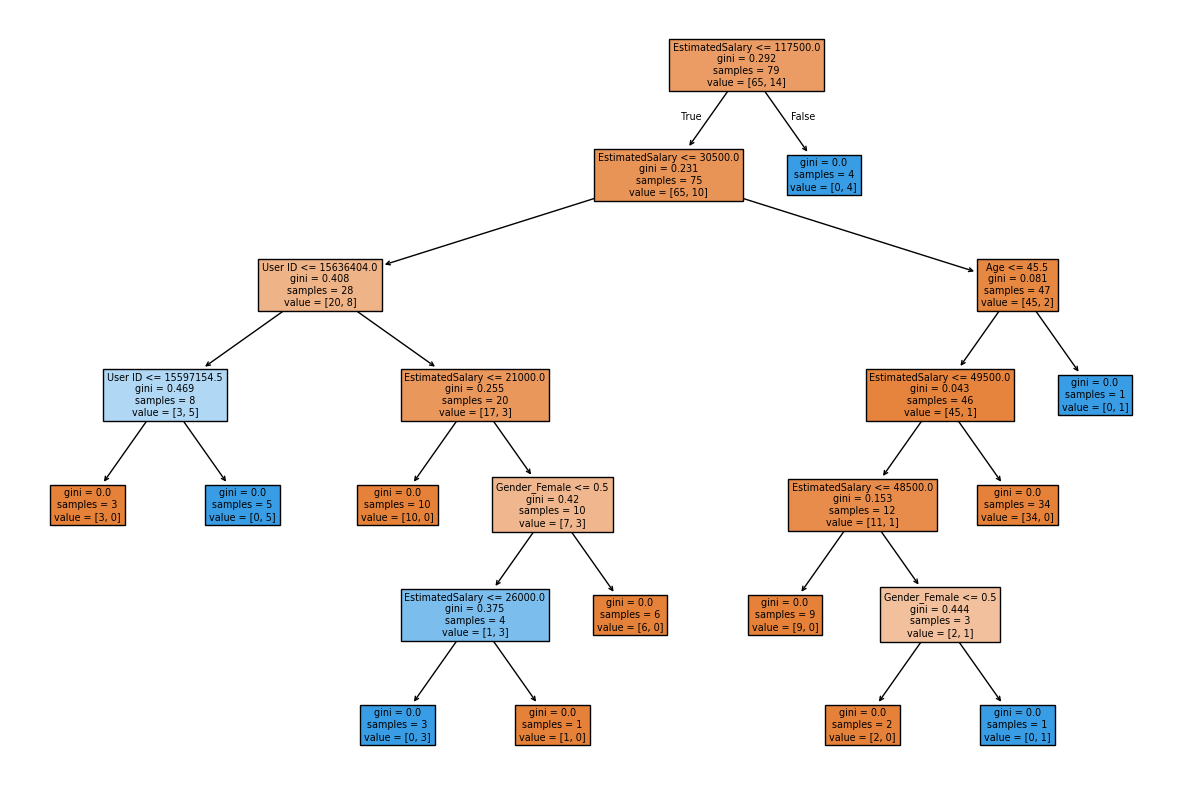

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(dtc,feature_names=user_encoded.columns,filled=True)
plt.show()

In [15]:
train_accuracy = dtc.score(X_train,y_train)
print("Accuracy of the model on the train data = ",train_accuracy*100,"%")

test_accuracy = dtc.score(X_test,y_test)
print("Accurecy of the model on the test data = ",test_accuracy*100,"%")


Accuracy of the model on the train data =  100.0 %
Accurecy of the model on the test data =  75.0 %


Exercise 2: Naive Bayes Classifier

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [19]:
iris = load_iris()

In [20]:
X = iris.data
y = iris.target

In [21]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [22]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [23]:
print('Features name: ',iris.feature_names)
print("Target name: ",iris.target_names)

Features name:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target name:  ['setosa' 'versicolor' 'virginica']


In [25]:
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
X.shape

(150, 4)

In [32]:
X_train.shape

(120, 4)

In [33]:
X_test.shape

(30, 4)

In [34]:
y_train.shape

(120,)

In [35]:
y_test.shape

(30,)

In [39]:
model = GaussianNB()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [40]:
y_pred.shape

(30,)

In [41]:
print("Accuracy score: ",accuracy_score(y_test,y_pred)*100,"%")

Accuracy score:  100.0 %


In [42]:
print("Classification Report:\n",classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [43]:
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))

confusion_matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


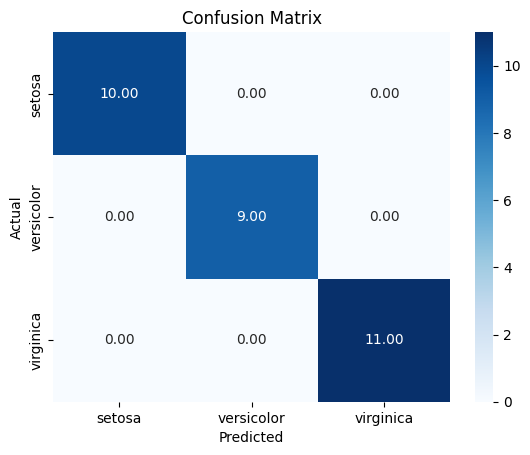

In [48]:
plt.figure()
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt=".2f",xticklabels=iris.target_names,yticklabels=iris.target_names,cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import accuracy_score, classification_report
warnings.filterwarnings("ignore")

In [3]:
spam_data = pd.read_csv('spambase.csv')

In [4]:
spam_data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [6]:
spam_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_req_our                4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [7]:
from sklearn.model_selection import train_test_split
features = spam_data.columns.drop("spam")
target = 'spam'
X = spam_data[features]
y = spam_data[target]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [8]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10,min_samples_split=20,min_impurity_decrease=0.05)
model.fit(X_train,y_train)
train_accuracy = model.score(X_train,y_train)
test_accuracy = model.score(X_test,y_test)

In [9]:
print("Train accuracy: ",train_accuracy)
print("Testing accuracy; ",test_accuracy)

Train accuracy:  0.8570652173913044
Testing accuracy;  0.8479913137893594


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=10)
model.fit(X_train,y_train)
train_accuracy = model.score(X_train,y_train)
test_accuracy = model.score(X_test,y_test)
print("Train accuracy: ",train_accuracy*100)
print("Testing accuracy; ",test_accuracy*100)

Train accuracy:  90.70652173913044
Testing accuracy;  90.33659066232356


In [ ]:
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SVM Model
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Load dataset
df = pd.read_csv("iris.csv")

# Display first 5 rows
print(df.head())

# Check dataset info
print(df.info())

In [ ]:
le = LabelEncoder()

df['species'] = le.fit_transform(df['species'])

print(df.head())